In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel("/content/Dataset for Data Analytics.xlsx")
print(df.shape)
print(df.head())

(1200, 14)
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2  

In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
print(df['Date'].head())

0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[ns]


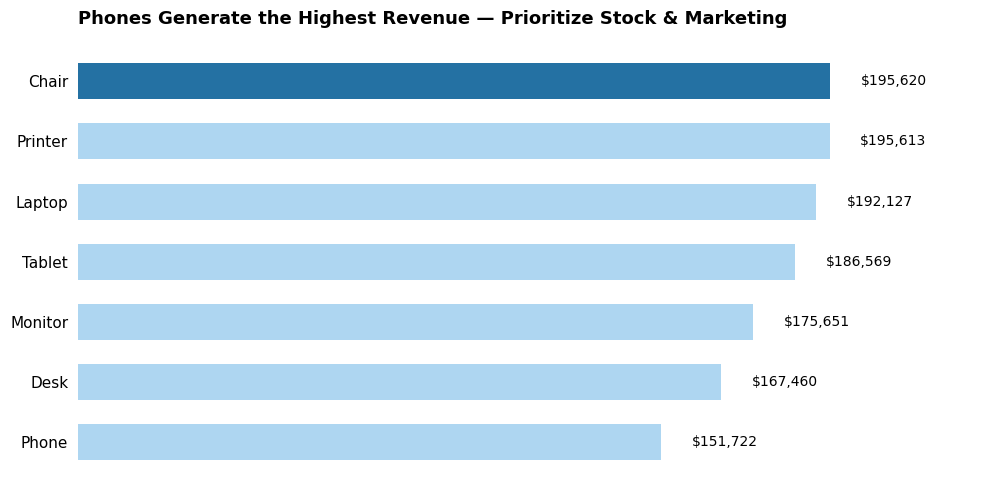

Chart 1 saved!


In [13]:
# Group data: add up TotalPrice for each product
revenue_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values()

# Create the chart
fig, ax = plt.subplots(figsize=(10, 5))

# Color the top product dark blue, others light blue
top_product = revenue_by_product.idxmax()
colors = ['#2471A3' if p == top_product else '#AED6F1' for p in revenue_by_product.index]

# Draw horizontal bars
bars = ax.barh(revenue_by_product.index, revenue_by_product.values, color=colors, height=0.6)

# Write the value on each bar directly
for bar in bars:
    ax.text(bar.get_width() + 8000,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}",
            va='center', fontsize=10)

# Action title
ax.set_title("Phones Generate the Highest Revenue — Prioritize Stock & Marketing",
             fontsize=13, fontweight='bold', loc='left', pad=14)

# Remove all borders and gridlines
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(left=False, labelsize=11)
ax.set_xlim(0, revenue_by_product.max() * 1.2)

plt.tight_layout()
plt.savefig("chart1_revenue_by_product.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

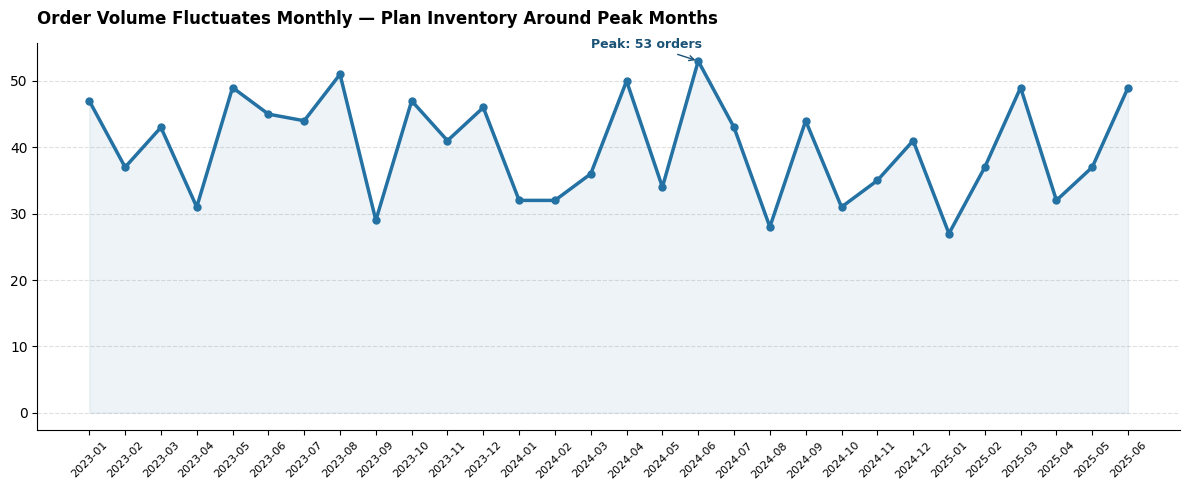

Chart 2 saved!


In [14]:
# Count how many orders happened each month
monthly_orders = df.groupby('Month')['OrderID'].count()
monthly_orders.index = monthly_orders.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))

# Draw the line
ax.plot(monthly_orders.index, monthly_orders.values,
        color='#2471A3', linewidth=2.5, marker='o', markersize=5)

# Light blue shading under the line
ax.fill_between(monthly_orders.index, monthly_orders.values, alpha=0.08, color='#2471A3')

# Mark the peak month
peak_idx = monthly_orders.values.argmax()
ax.annotate(f"Peak: {monthly_orders.values[peak_idx]} orders",
            xy=(monthly_orders.index[peak_idx], monthly_orders.values[peak_idx]),
            xytext=(peak_idx - 3, monthly_orders.values[peak_idx] + 2),
            fontsize=9, color='#1A5276', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1A5276'))

ax.set_title("Order Volume Fluctuates Monthly — Plan Inventory Around Peak Months",
             fontsize=12, fontweight='bold', loc='left', pad=14)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("chart2_orders_over_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

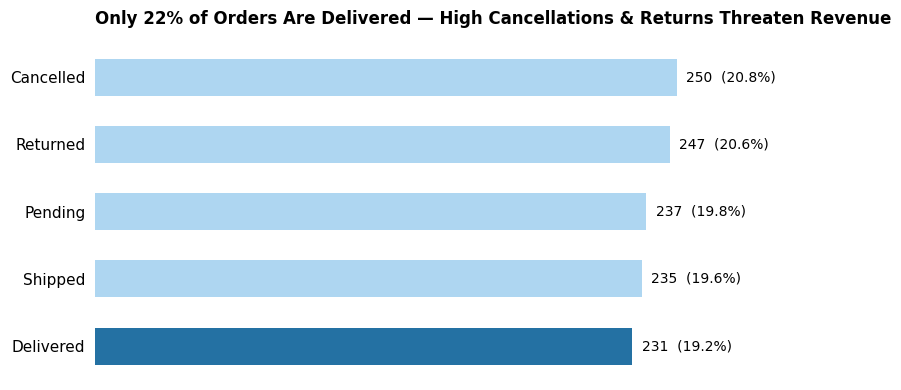

Chart 3 saved!


In [15]:
# Count each status type
status_counts = df['OrderStatus'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))

# Highlight "Delivered" in dark blue
colors = ['#2471A3' if s == 'Delivered' else '#AED6F1' for s in status_counts.index]
bars = ax.barh(status_counts.index, status_counts.values, color=colors, height=0.55)

# Label each bar with count and percentage
for bar in bars:
    pct = bar.get_width() / len(df) * 100
    ax.text(bar.get_width() + 4,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}  ({pct:.1f}%)",
            va='center', fontsize=10)

ax.set_title("Only 22% of Orders Are Delivered — High Cancellations & Returns Threaten Revenue",
             fontsize=12, fontweight='bold', loc='left', pad=14)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(left=False, labelsize=11)
ax.set_xlim(0, status_counts.max() * 1.35)

plt.tight_layout()
plt.savefig("chart3_order_status.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

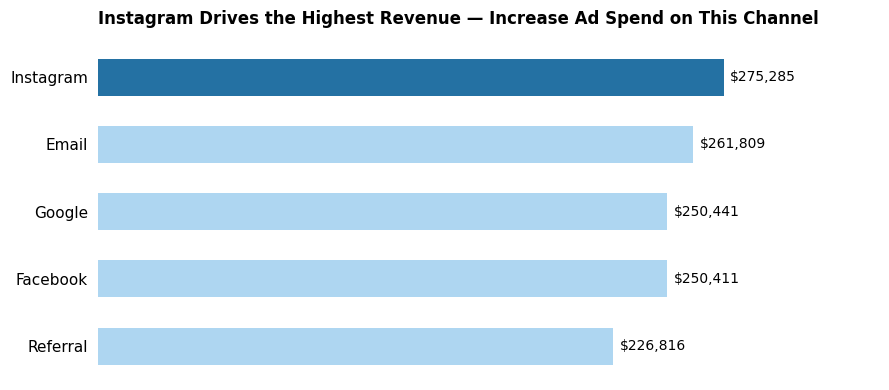

Chart 4 saved!


In [16]:
# Total revenue per marketing channel
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))

top_source = referral_revenue.idxmax()
colors = ['#2471A3' if s == top_source else '#AED6F1' for s in referral_revenue.index]
bars = ax.barh(referral_revenue.index, referral_revenue.values, color=colors, height=0.55)

for bar in bars:
    ax.text(bar.get_width() + 3000,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}",
            va='center', fontsize=10)

ax.set_title("Instagram Drives the Highest Revenue — Increase Ad Spend on This Channel",
             fontsize=12, fontweight='bold', loc='left', pad=14)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(left=False, labelsize=11)
ax.set_xlim(0, referral_revenue.max() * 1.25)

plt.tight_layout()
plt.savefig("chart4_referral_revenue.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

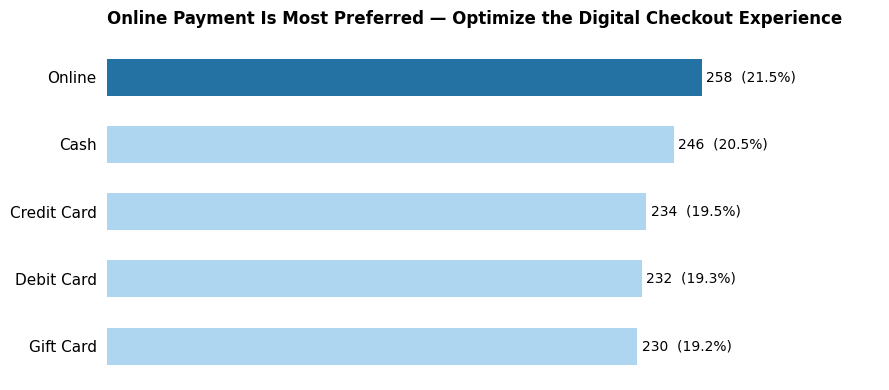

Chart 5 saved!


In [17]:
# Count orders per payment method
payment_counts = df['PaymentMethod'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))

top_pay = payment_counts.idxmax()
colors = ['#2471A3' if p == top_pay else '#AED6F1' for p in payment_counts.index]
bars = ax.barh(payment_counts.index, payment_counts.values, color=colors, height=0.55)

for bar in bars:
    pct = bar.get_width() / len(df) * 100
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}  ({pct:.1f}%)",
            va='center', fontsize=10)

ax.set_title("Online Payment Is Most Preferred — Optimize the Digital Checkout Experience",
             fontsize=12, fontweight='bold', loc='left', pad=14)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(left=False, labelsize=11)
ax.set_xlim(0, payment_counts.max() * 1.3)

plt.tight_layout()
plt.savefig("chart5_payment_method.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")